# Low-Carbon Concrete Strength Prediction

## Leakage-safe Regression and Concrete Recipe Screening

Concrete strength depends nonlinearly on its ingredients and curing age. This
project develops a supervised regression model to predict compressive strength
in megapascals (MPa).

The workflow includes:

1. Exploratory analysis of ingredients, age, and strength
2. Grouped validation by concrete recipe
3. Comparison with simple regression baselines
4. Hyperparameter tuning of a gradient-boosting model
5. Untouched grouped test evaluation
6. Bootstrap uncertainty analysis
7. Permutation feature importance
8. Screening of observed lower-cement concrete mixtures

Grouping is important because the same ingredient composition may appear at
different curing ages. Allowing the same recipe into both training and testing
could produce an overly optimistic evaluation.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GroupKFold, GroupShuffleSplit, RandomizedSearchCV, cross_validate
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [2]:
concrete = fetch_ucirepo(id=165)

X = concrete.data.features.copy()
y = concrete.data.targets.iloc[:, 0].copy()

X.columns = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_aggregate", "fine_aggregate", "age"
]
y.name = "strength_mpa"

data = pd.concat([X, y], axis=1)

print(f"Rows: {len(data):,}")
print(f"Features: {X.shape[1]}")
print(f"Missing values: {data.isna().sum().sum()}")
display(data.head())

Rows: 1,030
Features: 8
Missing values: 0


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength_mpa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.17,104.51,102.00,192.38,272.90,350.00,540.0
slag,1030.0,73.90,86.28,0.00,0.00,22.00,142.95,359.4
fly_ash,1030.0,54.19,64.00,0.00,0.00,0.00,118.30,200.1
water,1030.0,181.57,21.35,121.80,164.90,185.00,192.00,247.0
superplasticizer,1030.0,6.20,5.97,0.00,0.00,6.40,10.20,32.2
coarse_aggregate,1030.0,972.92,77.75,801.00,932.00,968.00,1029.40,1145.0
fine_aggregate,1030.0,773.58,80.18,594.00,730.95,779.50,824.00,992.6
age,1030.0,45.66,63.17,1.00,7.00,28.00,56.00,365.0
strength_mpa,1030.0,35.82,16.71,2.33,23.71,34.44,46.14,82.6


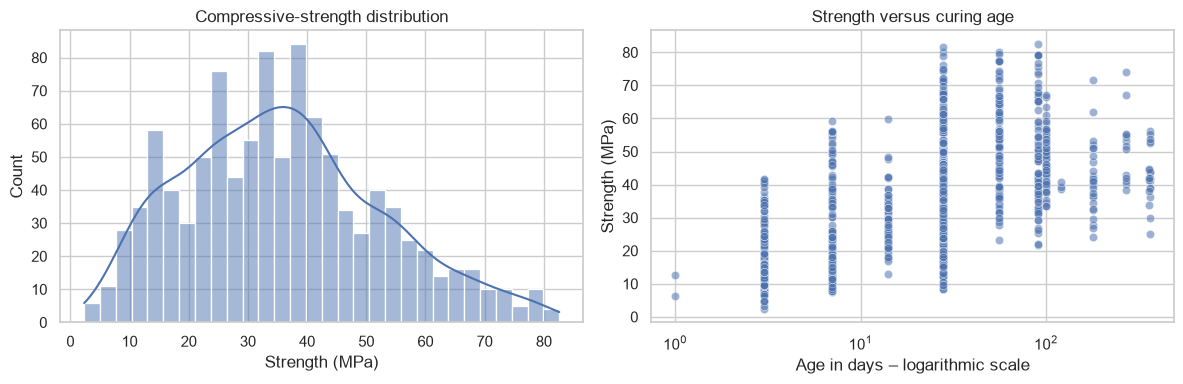

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))plt.figure(figsize=(10, 7))
sns.heatmap(data.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature and target correlations")
plt.tight_layout()
plt.show()

sns.histplot(data=data, x="strength_mpa", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Compressive-strength distribution")
axes[0].set_xlabel("Strength (MPa)")

sns.scatterplot(data=data, x="age", y="strength_mpa", alpha=0.55, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Strength versus curing age")
axes[1].set_xlabel("Age in days – logarithmic scale")
axes[1].set_ylabel("Strength (MPa)")

plt.tight_layout()
plt.show()

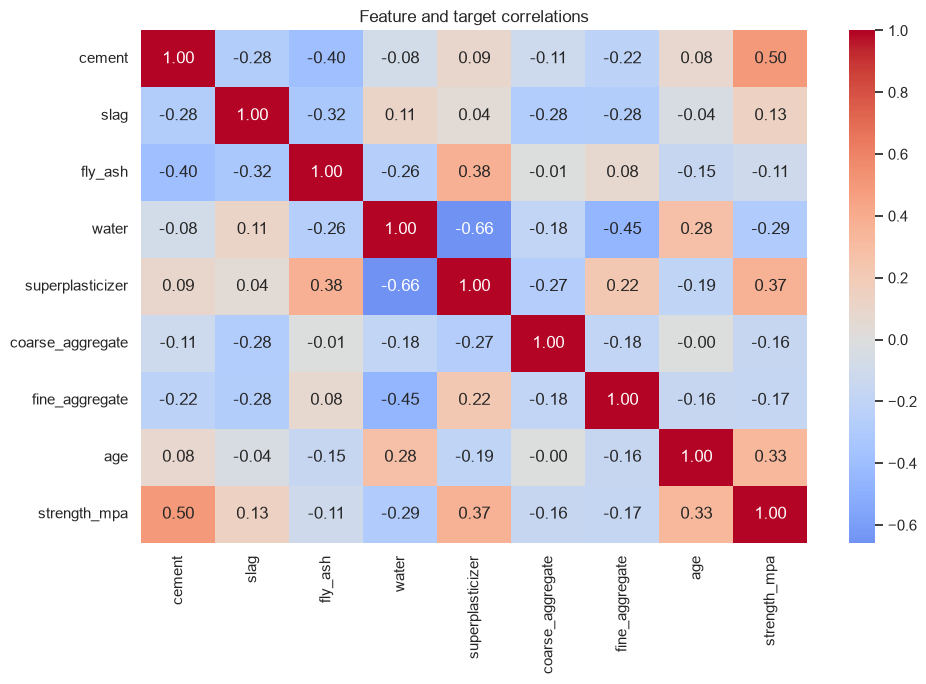

In [5]:
plt.figure(figsize=(10, 7))
sns.heatmap(data.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature and target correlations")
plt.tight_layout()
plt.show()

## Initial data observations

- The dataset contains **1,030 concrete samples** and **8 numerical input
  features**, with **no missing values**.
- Compressive strength ranged from **2.33 to 82.60 MPa**, with a median of
  **34.44 MPa**.
- Cement had the strongest positive correlation with strength (**0.50**),
  followed by superplasticizer (**0.37**) and curing age (**0.33**).
- Water had the strongest negative correlation with strength (**-0.29**).
  Fine aggregate (**-0.17**) and coarse aggregate (**-0.16**) also had weak
  negative correlations.
- Strength generally increased with curing age, but the relationship was
  nonlinear: strength increased rapidly at younger ages and then became less
  responsive as concrete matured.
- The correlations and scatter plot suggest that a nonlinear model is more
  appropriate than a purely linear relationship. These correlations are
  descriptive and should not be interpreted as causal effects.

## Recipe-based grouping

A concrete recipe is defined by its seven ingredient quantities, excluding
curing age.

Samples with the same ingredients but different ages receive the same group
identifier. Group-based splitting prevents the model from seeing the same
mixture composition during both training and testin.

In [6]:
INGREDIENTS = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_aggregate", "fine_aggregate"
]

recipe_groups = X[INGREDIENTS].round(3).astype(str).agg("|".join, axis=1)
recipe_sizes = recipe_groups.value_counts()

print(f"Unique recipes: {recipe_groups.nunique():,}")
print(f"Recipes appearing more than once: {(recipe_sizes > 1).sum():,}")
print(f"Largest recipe group: {recipe_sizes.max()} samples")
display(recipe_sizes.describe().round(2))

Unique recipes: 427
Recipes appearing more than once: 181
Largest recipe group: 20 samples


count    427.00
mean       2.41
std        2.13
min        1.00
25%        1.00
50%        1.00
75%        4.00
max       20.00
Name: count, dtype: float64

In [7]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
development_idx, test_idx = next(splitter.split(X, y, groups=recipe_groups))

X_development, X_test = X.iloc[development_idx], X.iloc[test_idx]
y_development, y_test = y.iloc[development_idx], y.iloc[test_idx]
development_groups = recipe_groups.iloc[development_idx]
test_groups = recipe_groups.iloc[test_idx]

print(f"Development samples: {len(X_development):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Development recipes: {development_groups.nunique():,}")
print(f"Test recipes: {test_groups.nunique():,}")
print(f"Recipe overlap: {len(set(development_groups) & set(test_groups))}")

Development samples: 837
Test samples: 193
Development recipes: 341
Test recipes: 86
Recipe overlap: 0


## Grouping and split observations

- The dataset contained **427 unique concrete recipes**.
- **181 recipes** appeared more than once, usually at different curing ages.
  The largest recipe group contained **20 samples**.
- The development set contained **837 samples from 341 recipes**, while the
  untouched test set contained **193 samples from 86 recipes**.
- There were **zero overlapping recipe groups**, confirming that identical
  concrete mixtures did not cross the development–test boundary.
- This grouped test is more demanding than an ordinary random split because the
  model must generalize to ingredient combinations that were not observed
  during training.

In [8]:
models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Ridge regression": make_pipeline(StandardScaler(), Ridge(alpha=10)),
    "Gradient boosting": HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
        min_samples_leaf=20, random_state=RANDOM_STATE
    )
}

group_cv = GroupKFold(n_splits=5)
cv_rows = []

for name, model in models.items():
    scores = cross_validate(
        model, X_development, y_development,
        groups=development_groups, cv=group_cv,
        scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
        n_jobs=-1
    )
    cv_rows.append({
        "model": name,
        "mean_mae": -scores["test_mae"].mean(),
        "std_mae": scores["test_mae"].std(),
        "mean_r2": scores["test_r2"].mean(),
        "std_r2": scores["test_r2"].std()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("mean_mae")
cv_results.round(3)

,model,mean_mae,std_mae,mean_r2,std_r2
2,Gradient boosting,4.345,0.611,0.870,0.032
1,Ridge regression,8.492,0.632,0.598,0.034
0,Mean baseline,13.714,0.567,-0.011,0.013


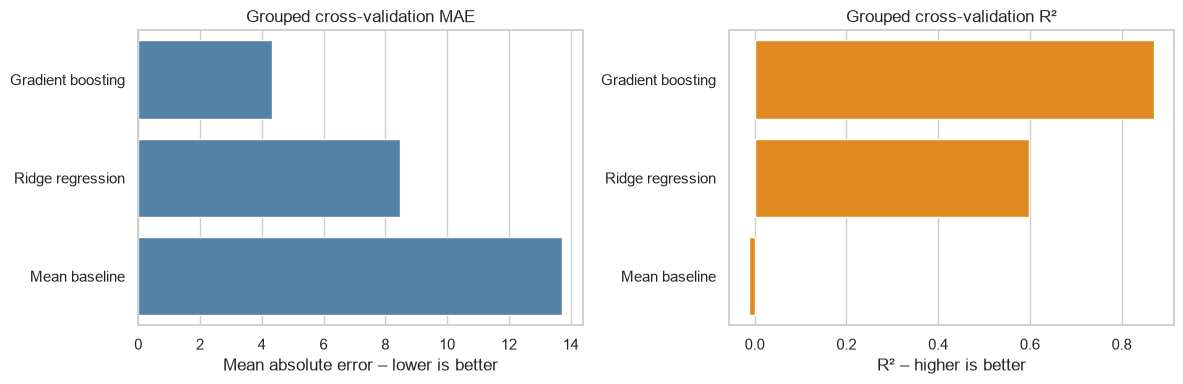

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=cv_results, x="mean_mae", y="model", color="steelblue", ax=axes[0])
axes[0].set_title("Grouped cross-validation MAE")
axes[0].set_xlabel("Mean absolute error – lower is better")
axes[0].set_ylabel("")

sns.barplot(data=cv_results, x="mean_r2", y="model", color="darkorange", ax=axes[1])
axes[1].set_title("Grouped cross-validation R²")
axes[1].set_xlabel("R² – higher is better")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Baseline comparison

- The mean-prediction baseline produced a grouped cross-validation MAE of
  **13.714 MPa** and an R² of **-0.011**.
- Ridge regression reduced MAE to **8.492 MPa** and increased R² to **0.598**,
  confirming that the ingredient and age variables contain useful predictive
  information.
- Gradient boosting achieved the best initial result, with MAE =
  **4.345 MPa** and R² = **0.870**.
- Compared with Ridge, gradient boosting reduced cross-validation MAE by
  **4.147 MPa**, or approximately **48.8%**.
- This large improvement indicates that nonlinear relationships and
  interactions between curing age, cement, water, and replacement materials
  are important for predicting concrete strength.

In [10]:
parameter_space = {
    "learning_rate": [0.025, 0.05, 0.075, 0.10],
    "max_iter": [200, 300, 450, 600],
    "max_leaf_nodes": [7, 15, 23, 31],
    "min_samples_leaf": [10, 15, 20, 30],
    "l2_regularization": [0, 0.1, 1, 5]
}

search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    parameter_space, n_iter=30, scoring="neg_mean_absolute_error",
    cv=group_cv, random_state=RANDOM_STATE, n_jobs=-1,
    return_train_score=True
)

search.fit(
    X_development, y_development,
    groups=development_groups
)

print(f"Best grouped CV MAE: {-search.best_score_:.3f} MPa")
print("Best parameters:")
for parameter, value in search.best_params_.items():
    print(f"  {parameter}: {value}")

Best grouped CV MAE: 4.132 MPa
Best parameters:
  min_samples_leaf: 15
  max_leaf_nodes: 31
  max_iter: 450
  learning_rate: 0.1
  l2_regularization: 1


In [11]:
search_results = pd.DataFrame(search.cv_results_)
tuning_table = search_results[
    ["rank_test_score", "mean_test_score", "std_test_score", "mean_train_score", "params"]
].sort_values("rank_test_score").head(10)

tuning_table["mean_test_mae"] = -tuning_table["mean_test_score"]
tuning_table["mean_train_mae"] = -tuning_table["mean_train_score"]

tuning_table[
    ["rank_test_score", "mean_test_mae", "std_test_score", "mean_train_mae", "params"]
].round(3)

,rank_test_score,mean_test_mae,std_test_score,mean_train_mae,params
19,1,4.132,0.461,0.504,"{'min_samples_leaf': 15, 'max_leaf_nodes': 31,..."
7,2,4.151,0.621,0.855,"{'min_samples_leaf': 20, 'max_leaf_nodes': 31,..."
4,3,4.215,0.565,1.050,"{'min_samples_leaf': 20, 'max_leaf_nodes': 23,..."
14,4,4.220,0.406,0.805,"{'min_samples_leaf': 15, 'max_leaf_nodes': 31,..."
12,5,4.225,0.576,0.992,"{'min_samples_leaf': 15, 'max_leaf_nodes': 15,..."
26,6,4.226,0.613,1.030,"{'min_samples_leaf': 20, 'max_leaf_nodes': 23,..."
25,7,4.228,0.481,0.529,"{'min_samples_leaf': 10, 'max_leaf_nodes': 23,..."
2,8,4.248,0.516,0.390,"{'min_samples_leaf': 10, 'max_leaf_nodes': 31,..."
18,9,4.256,0.544,1.105,"{'min_samples_leaf': 10, 'max_leaf_nodes': 15,..."
15,10,4.263,0.480,1.003,"{'min_samples_leaf': 15, 'max_leaf_nodes': 31,..."


## Model tuning findings

- The selected model used **31 maximum leaf nodes**, **15 minimum samples per
  leaf**, **450 boosting iterations**, a **0.10 learning rate**, and
  **L2 regularization of 1**.
- Its grouped cross-validation MAE was **4.132 MPa**.
- Tuning improved MAE by **0.213 MPa**, or approximately **4.9%**, compared
  with the initial gradient-boosting model.
- The selected model had training MAE = **0.504 MPa**, producing a large gap of
  approximately **3.628 MPa** relative to grouped validation.
- This gap indicates substantial fitting to the development recipes. However,
  the grouped validation design measures performance on unseen recipes, and
  the later test MAE remained close to the cross-validation estimate.
- Hyperparameters were selected without accessing the untouched test recipes.

In [12]:
ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=10))
ridge_model.fit(X_development, y_development)

best_model = search.best_estimator_
ridge_predictions = ridge_model.predict(X_test)
boosting_predictions = best_model.predict(X_test)

def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted)
    }

test_results = pd.DataFrame({
    "Ridge regression": regression_metrics(y_test, ridge_predictions),
    "Gradient boosting": regression_metrics(y_test, boosting_predictions)
}).T

test_results.round(3)

,MAE,RMSE,R2
Ridge regression,7.782,10.054,0.571
Gradient boosting,4.186,5.966,0.849


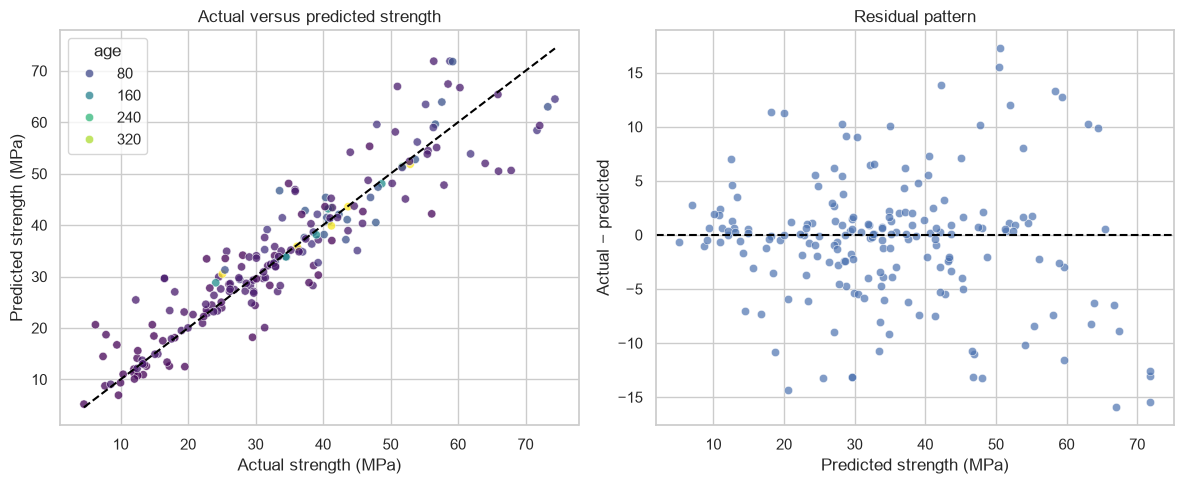

In [13]:
residuals = pd.DataFrame({
    "actual": y_test,
    "predicted": boosting_predictions,
    "residual": y_test.to_numpy() - boosting_predictions,
    "absolute_error": np.abs(y_test.to_numpy() - boosting_predictions),
    "age": X_test["age"]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=residuals, x="actual", y="predicted", hue="age",
                palette="viridis", alpha=0.75, ax=axes[0])
limits = [residuals[["actual", "predicted"]].min().min(),
          residuals[["actual", "predicted"]].max().max()]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set_title("Actual versus predicted strength")
axes[0].set_xlabel("Actual strength (MPa)")
axes[0].set_ylabel("Predicted strength (MPa)")

sns.scatterplot(data=residuals, x="predicted", y="residual", alpha=0.7, ax=axes[1])
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Residual pattern")
axes[1].set_xlabel("Predicted strength (MPa)")
axes[1].set_ylabel("Actual − predicted")

plt.tight_layout()
plt.show()

Mean MAE improvement over Ridge: 3.596 MPa
95% bootstrap interval: [2.641, 4.538] MPa


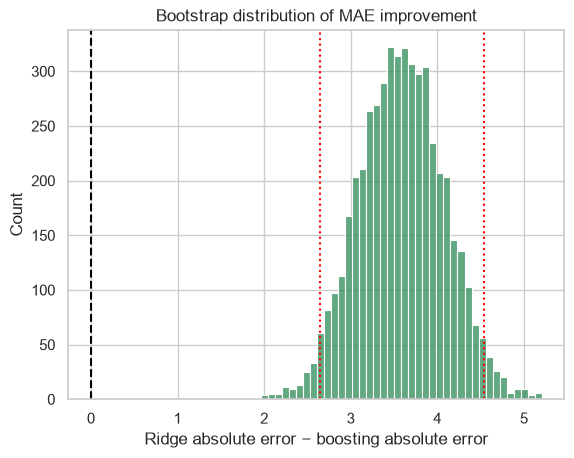

In [14]:
ridge_errors = np.abs(y_test.to_numpy() - ridge_predictions)
boosting_errors = np.abs(y_test.to_numpy() - boosting_predictions)
mae_savings = ridge_errors - boosting_errors

rng = np.random.default_rng(RANDOM_STATE)
bootstrap_improvements = np.array([
    rng.choice(mae_savings, len(mae_savings), replace=True).mean()
    for _ in range(5000)
])

lower, upper = np.quantile(bootstrap_improvements, [0.025, 0.975])

print(f"Mean MAE improvement over Ridge: {mae_savings.mean():.3f} MPa")
print(f"95% bootstrap interval: [{lower:.3f}, {upper:.3f}] MPa")

sns.histplot(bootstrap_improvements, bins=40, color="seagreen")
plt.axvline(0, color="black", linestyle="--")
plt.axvline(lower, color="red", linestyle=":")
plt.axvline(upper, color="red", linestyle=":")
plt.title("Bootstrap distribution of MAE improvement")
plt.xlabel("Ridge absolute error − boosting absolute error")
plt.show()

## Test set results

- Ridge regression achieved MAE = **7.782 MPa**, RMSE = **10.054 MPa**, and
  R² = **0.571**.
- Gradient boosting achieved MAE = **4.186 MPa**, RMSE = **5.966 MPa**, and
  R² = **0.849**.
- The nonlinear model reduced MAE by **3.596 MPa**, equivalent to approximately
  **46.2%**, on previously unseen concrete recipes.
- The 95% bootstrap interval for the mean MAE improvement was
  **[2.641, 4.538] MPa**.
- Because the entire interval is above zero, the test results provide strong
  evidence that gradient boosting outperformed Ridge for these recipes.
- Most predictions were close to the identity line, but residual variability
  increased at higher predicted strengths. The model was therefore less
  reliable for some high-strength mixtures than for ordinary-strength concrete.

In [15]:
residuals["age_band"] = pd.cut(
    residuals["age"], bins=[0, 7, 28, 90, np.inf],
    labels=["1–7 days", "8–28 days", "29–90 days", "Over 90 days"]
)

age_errors = residuals.groupby("age_band", observed=True).agg(
    samples=("absolute_error", "size"),
    mae=("absolute_error", "mean"),
    mean_residual=("residual", "mean")
).reset_index()

age_errors.round(3)

,age_band,samples,mae,mean_residual
0,1–7 days,43,4.726,-0.879
1,8–28 days,98,3.932,-0.500
2,29–90 days,25,5.155,-0.325
3,Over 90 days,27,3.353,-1.110


,strength_band,samples,mae,mean_residual
0,Lowest,49,3.437,-2.210
1,Lower-middle,48,3.159,-1.005
2,Upper-middle,48,3.657,-0.243
3,Highest,48,6.508,0.902


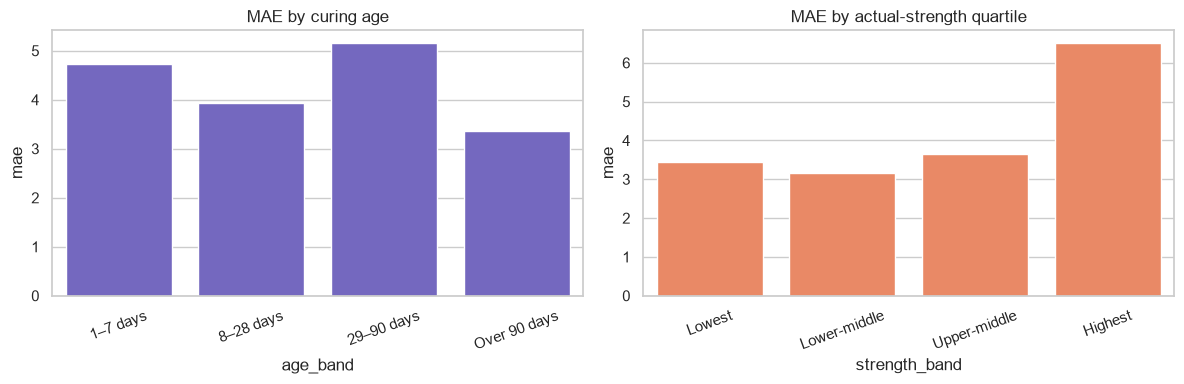

In [16]:
residuals["strength_band"] = pd.qcut(
    residuals["actual"], q=4,
    labels=["Lowest", "Lower-middle", "Upper-middle", "Highest"]
)

strength_errors = residuals.groupby("strength_band", observed=True).agg(
    samples=("absolute_error", "size"),
    mae=("absolute_error", "mean"),
    mean_residual=("residual", "mean")
).reset_index()

display(strength_errors.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=age_errors, x="age_band", y="mae", color="slateblue", ax=axes[0])
axes[0].set_title("MAE by curing age")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=strength_errors, x="strength_band", y="mae",
            color="coral", ax=axes[1])
axes[1].set_title("MAE by actual-strength quartile")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Error analysis 

- The lowest age-group MAE occurred for concrete older than 90 days at
  **3.353 MPa**.
- The highest age-group MAE occurred between 29 and 90 days at **5.155 MPa**.
- Mean residuals were negative in every age group, indicating slight average
  overprediction. The strongest age-based overprediction occurred after
  90 days, with a mean residual of **-1.110 MPa**.
- The lower strength quartiles were generally overpredicted. The lowest
  quartile had a mean residual of **-2.210 MPa**, while the highest quartile
  was underpredicted by an average of **0.902 MPa**.
- The highest-strength quartile had MAE = **6.508 MPa**, compared with
  **3.437 MPa** for the lowest quartile. The lower-middle quartile had the
  lowest overall MAE at **3.159 MPa**.
- This pattern suggests regression toward the centre: very weak concrete was
  predicted too highly, while very strong concrete was predicted too low.
- Model reliability was therefore uneven across strength levels, with the
  largest errors concentrated among high-strength mixtures.

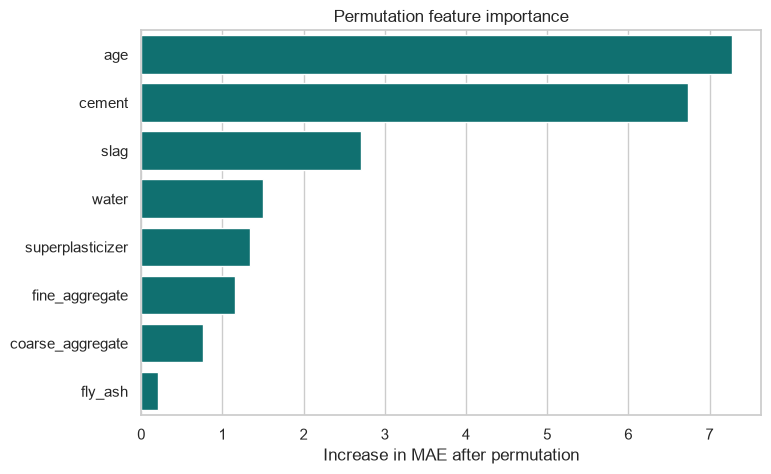

,feature,mae_increase,std
7,age,7.273,0.451
0,cement,6.736,0.443
1,slag,2.713,0.193
3,water,1.500,0.225
4,superplasticizer,1.334,0.149
6,fine_aggregate,1.154,0.117
5,coarse_aggregate,0.763,0.141
2,fly_ash,0.208,0.069


In [17]:
importance_result = permutation_importance(
    best_model, X_test, y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1
)

importance = pd.DataFrame({
    "feature": X.columns,
    "mae_increase": importance_result.importances_mean,
    "std": importance_result.importances_std
}).sort_values("mae_increase", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="mae_increase", y="feature", color="teal")
plt.title("Permutation feature importance")
plt.xlabel("Increase in MAE after permutation")
plt.ylabel("")
plt.show()

importance.round(3)

## Feature importance 

- Curing age was the most influential feature, followed closely by cement
  quantity.
- Permuting age increased MAE by approximately **7.273 MPa**, while permuting
  cement increased it by **6.736 MPa**.
- Slag was the third most important variable, increasing MAE by **2.713 MPa**
  when permuted.
- Water (**1.500 MPa**), superplasticizer (**1.334 MPa**), and fine aggregate
  (**1.154 MPa**) provided moderate predictive information.
- Fly ash had the lowest measured importance at **0.208 MPa**, suggesting that
  it contributed relatively little additional information after the remaining
  ingredient variables were considered.
- Permutation importance measures predictive dependence rather than causality.
  A correlated feature may appear less important when similar information is
  already available from another ingredient.

## Lower-cement recipe screening

The following analysis does not generate new concrete formulas. It screens
observed 28-day test recipes that the model predicts will reach at least
40 MPa.

Recipes are ranked by cement content, and supplementary cementitious material
share is calculated from blast-furnace slag and fly ash.

These results are exploratory model outputs, not validated engineering mix
recommendations.

In [18]:
TARGET_STRENGTH = 40

screening = X_test.copy()
screening["actual_strength"] = y_test
screening["predicted_strength"] = boosting_predictions

binder = screening["cement"] + screening["slag"] + screening["fly_ash"]
screening["scm_share"] = (
    (screening["slag"] + screening["fly_ash"]) / binder.replace(0, np.nan)
)

shortlist = screening[
    screening["age"].between(27, 29)
    & (screening["predicted_strength"] >= TARGET_STRENGTH)
].sort_values(["cement", "predicted_strength"], ascending=[True, False])

columns = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "age", "scm_share", "predicted_strength", "actual_strength"
]

display(shortlist[columns].head(10).round(3))
print(f"Qualifying observed recipes: {len(shortlist)}")

,cement,slag,fly_ash,water,superplasticizer,age,scm_share,predicted_strength,actual_strength
1000,141.9,166.6,129.7,173.5,10.9,28,0.676,43.700,44.61
435,167.4,129.9,128.6,175.5,7.8,28,0.607,45.213,41.20
366,214.9,53.8,121.9,155.6,9.6,28,0.450,45.088,52.20
400,250.0,180.0,95.0,159.0,9.5,28,0.524,50.623,67.87
8,266.0,114.0,0.0,228.0,0.0,28,0.300,40.329,45.85
847,280.0,129.0,100.0,172.0,9.0,28,0.450,52.418,52.82
1020,288.4,121.0,0.0,177.4,7.0,28,0.296,41.483,42.14
913,298.0,0.0,107.0,164.0,13.0,28,0.264,46.900,35.86
976,298.1,0.0,107.5,163.6,12.8,28,0.265,46.575,35.87
914,313.0,145.0,0.0,178.0,8.0,28,0.317,41.390,41.05


Qualifying observed recipes: 28


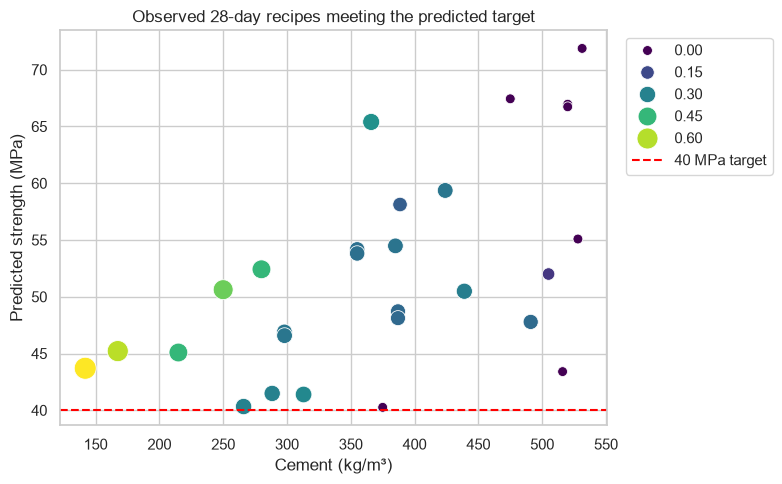

In [19]:
if len(shortlist):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=shortlist, x="cement", y="predicted_strength",
        size="scm_share", hue="scm_share", palette="viridis",
        sizes=(50, 250)
    )
    plt.axhline(TARGET_STRENGTH, color="red", linestyle="--",
                label=f"{TARGET_STRENGTH} MPa target")
    plt.title("Observed 28-day recipes meeting the predicted target")
    plt.xlabel("Cement (kg/m³)")
    plt.ylabel("Predicted strength (MPa)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Recipe screening findings

- **28 observed 28-day recipes** had predicted strength of at least 40 MPa.
- The lowest-cement qualifying recipe contained **141.9 kg/m³ of cement** and
  had predicted strength of **43.700 MPa**.
- Its supplementary cementitious material share was **67.6%**, consisting of
  166.6 kg/m³ of slag and 129.7 kg/m³ of fly ash.
- Its measured strength was **44.61 MPa**, so the model underpredicted its
  strength by only **0.91 MPa**.
- The shortlist nevertheless contained some false-positive candidates. For
  example, two displayed recipes were predicted above 46 MPa but had measured
  strengths of approximately 35.9 MPa.
- The screening results therefore demonstrate how regression can prioritize
  candidates for investigation, but a predicted value above 40 MPa does not
  guarantee that the measured strength will satisfy the target.
- Cement quantity is only a rough sustainability proxy. Actual low-carbon
  assessment would require embodied-carbon coefficients for cement, slag,
  fly ash, transport, and the other ingredients.
- Laboratory testing and engineering validation remain necessary before any
  mixture could be considered safe or practical.